In [4]:
#load the cleaned data fresh
import pandas as pd

weekly_clean = pd.read_csv('../data/processed/weekly_clean.csv')
weekly_clean['week'] = pd.to_datetime(weekly_clean['week'])

weekly_clean.head()

,week,total_orders,total_return_proxy,avg_delivery_delay,return_rate
0,2016-10-03,283.0,85.0,-36.533898,0.300353
1,2017-01-16,197.0,25.0,-28.798942,0.126904
2,2017-01-23,354.0,61.0,-27.072289,0.172316
3,2017-01-30,467.0,71.0,-23.930556,0.152034
4,2017-02-06,548.0,70.0,-20.641879,0.127737


In [9]:
# Step 1 -> ADF test (check if the series is stationary)
#p-value < 0.05 → stationary, no fix needed
#p-value ≥ 0.05 → trending, needs differencing

from statsmodels.tsa.stattools import adfuller

result_ct = adfuller(weekly_clean['total_return_proxy'], regression='ct')  # constant + trend

print(f"ADF Statistic (with trend): {result_ct[0]}")
print(f"p-value (with trend): {result_ct[1]}")

if result_ct[1] < 0.05:
    print("=> Series is stationary")
else:
    print("=> Series is NOT stationary (has a trend) — needs differencing")

ADF Statistic (with trend): -3.3622535510311717
p-value (with trend): 0.056639155526110166
=> Series is NOT stationary (has a trend) — needs differencing


C:\Users\Dell\AppData\Local\Temp\ipykernel_5300\1622379863.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_ct = adfuller(weekly_clean['total_return_proxy'], regression='ct')  # constant + trend


In [10]:
#Step 2 -> Differencing
#Concept: Subtract each week's value from the previous week's value. 
#This removes the trend, turning the climbing line into something that hovers around zero (stable).

weekly_clean['diff_1'] = weekly_clean['total_return_proxy'].diff()

# Drop the first row (NaN, since there's no "previous week" for week 0)
diff_series = weekly_clean['diff_1'].dropna()

diff_series.head()

1   -60.0
2    36.0
3    10.0
4    -1.0
5    12.0
Name: diff_1, dtype: float64

In [11]:
#re-run the ADF test (with trend) on diff_series instead of the raw column:

result_diff = adfuller(diff_series, regression='ct')

print(f"ADF Statistic (differenced): {result_diff[0]}")
print(f"p-value (differenced): {result_diff[1]}")

if result_diff[1] < 0.05:
    print("=> Differenced series IS stationary — ready for modeling")
else:
    print("=> Still not stationary — may need a second round of differencing")

ADF Statistic (differenced): -6.07755549843666
p-value (differenced): 1.507192784189726e-06
=> Differenced series IS stationary — ready for modeling


C:\Users\Dell\AppData\Local\Temp\ipykernel_5300\3846858761.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(diff_series, regression='ct')


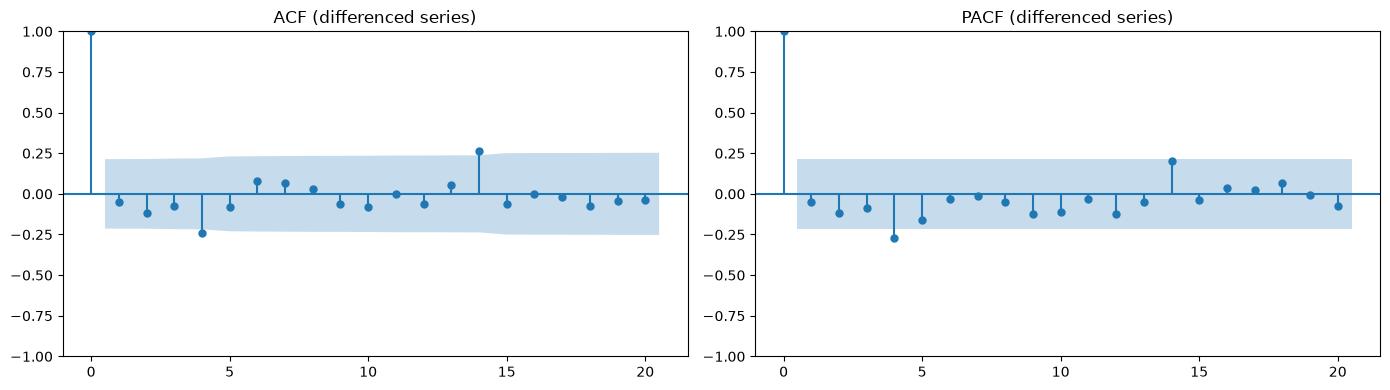

In [12]:
#Step 3: ACF/PACF plots
#Concept: Now that the series is stable (differenced), we check how many past weeks still relate to the current week.
# ACF shows overall correlation at each lag; PACF isolates the direct relationship at each lag, filtering out indirect chains.
# These help us pick SARIMA's p (autoregressive) and q (moving average) parameters.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff_series, lags=20, ax=axes[0])
plot_pacf(diff_series, lags=20, ax=axes[1])
axes[0].set_title('ACF (differenced series)')
axes[1].set_title('PACF (differenced series)')
plt.tight_layout()
plt.show()

#### Phase 2 conclusion, all three steps done:
#### Step 1 (ADF): raw series non-stationary (p=0.057 with trend)
#### Step 2 (differencing): 1 round of differencing → stationary (p≈0.0000015) → d=1
#### Step 3 (ACF/PACF): no strong short-term pattern → start with p=1, q=1, refine with auto_arima later